# Data Download: Cordillera Urubamba, Cusco Region

**Study Area**: Cordillera Urubamba, Cusco Region

**Priority**: MEDIUM

**Expected Results**:
- DEM tiles: ~2 tiles (~100 MB)
- Sentinel-2 scenes: ~24 files (8 years × 3 bands, 2017-2024, ~8 GB)
- Lake count: 20 glacial lakes
- GLOF events: 1 documented events

**Bounding Box**: [-72.2, -13.3, -71.8, -13.0] (WGS84)

**EPSG**: 32719 (UTM Zone 19S)

## 1. Setup and Configuration

In [1]:
# Core libraries
import sys
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Geospatial libraries
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from shapely.geometry import box
import numpy as np

# Planetary Computer
import pystac_client
import planetary_computer

# Visualization
import matplotlib.pyplot as plt

# Progress bar
from tqdm.auto import tqdm

print("Libraries imported successfully")
print(f"Execution started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Import download utility
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# Import and reload shared download functions
import importlib
import src.download
importlib.reload(src.download)
from src.download import download_study_area_data
from config_expanded_study_areas import EXPANDED_STUDY_AREAS

Libraries imported successfully
Execution started: 2026-02-19 10:17:05


## 2. Execute Download

Usando TODOS los años disponibles: 2017-2025 (9 años)
  GLOF Project >> CORDILLERA URUBAMBA, CUSCO REGION
  Bbox: [-72.2, -13.3, -71.8, -13.0]  |  EPSG:32719
  ~20 lagunas  |  1 GLOFs documentados
  Serie temporal: 2017–2025 (9 años)  |  Bandas: B02 B03 B04 B08 B11 B12

[DEM] NASADEM 30m
  [ok] NASADEM_HGT_s14w073  (1.3 MB, existente)
  [ok] NASADEM_HGT_s14w072  (1.3 MB, existente)
  [dl] NASADEM_HGT_s13w073 [3/4]... ok (0.0 MB)
  [dl] NASADEM_HGT_s13w072 [4/4]... ok (0.0 MB)
  Total: 4 tile(s)

[Sentinel-2 L2A] Temporada seca: meses [6, 7, 8]  |  nubosidad < 15%
  [ok] 2017  2017-07-24  cloud:5.0%  [B02 B03 B04 B08 B11 B12]  112.2 MB  (existentes)
  [ok] 2018  2018-06-19  cloud:0.8%  [B02 B03 B04 B08 B11 B12]  17.5 MB  (existentes)
  [ok] 2019  2019-08-18  cloud:0.8%  [B02 B03 B04 B08 B11 B12]  17.0 MB  (existentes)
  [ok] 2020  2020-06-08  cloud:1.8%  [B02 B03 B04 B08 B11 B12]  16.7 MB  (existentes)
  [ok] 2021  2021-07-23  cloud:0.1%  [B02 B03 B04 B08 B11 B12]  16.9 MB  (existentes)

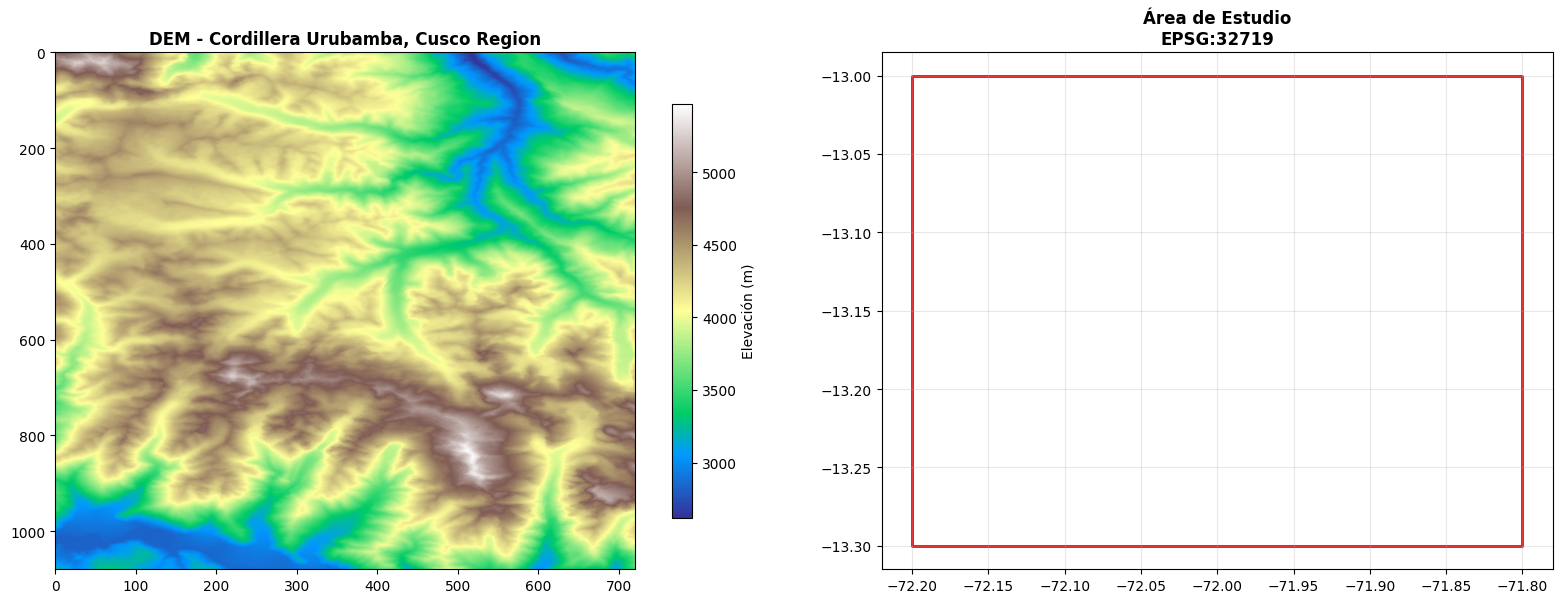

  Visualización guardada: /home/andre/Documents/GLOF_Andes_Project-Paper/figures/downloads/download_cordillera_urubamba.png
  Metadatos: /home/andre/Documents/GLOF_Andes_Project-Paper/data/raw/metadata_cordillera_urubamba.json
DESCARGA COMPLETADA EXITOSAMENTE

DOWNLOAD COMPLETE
Total data downloaded: 0.24 GB
DEM tiles: 4
Sentinel-2 years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Metadata saved to: /home/andre/Documents/GLOF_Andes_Project-Paper/data/raw/metadata_cordillera_urubamba.json


In [2]:
# Study area configuration
area_name = 'cordillera_urubamba'

# Execute download
# years=None: Uses ALL available years (2017-2025 = 9 years)
# This provides stronger temporal analysis for Nature Geoscience publication
results = download_study_area_data(
    area_name=area_name,
    years=None,  # ALL available years: 2017-2025 (9 years)
    months=[6, 7, 8],  # Dry season
    sentinel_bands=['B02', 'B03', 'B04', 'B08', 'B11', 'B12'],
    max_cloud_cover=15,
    visualize=True,
    save_metadata=True
)

if results['success']:
    print("\n" + "=" * 80)
    print("DOWNLOAD COMPLETE")
    print("=" * 80)
    print(f"Total data downloaded: {results['total_size_gb']:.2f} GB")
    print(f"DEM tiles: {results['dem_tiles']}")
    print(f"Sentinel-2 years: {results['sentinel_years']}")
    print(f"Metadata saved to: {results['metadata_path']}")
    print("=" * 80)
else:
    print("[ERROR] Download failed. Check error messages above.")
    raise RuntimeError(f"Download failed for {area_name}")